# 다룰 내용

- Sample 데이터를 만들어 KNN에 대해 이해한다.

In [10]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

# 1.데이터 준비

- 학습용 데이터를 만들고 데이터 분포 확인

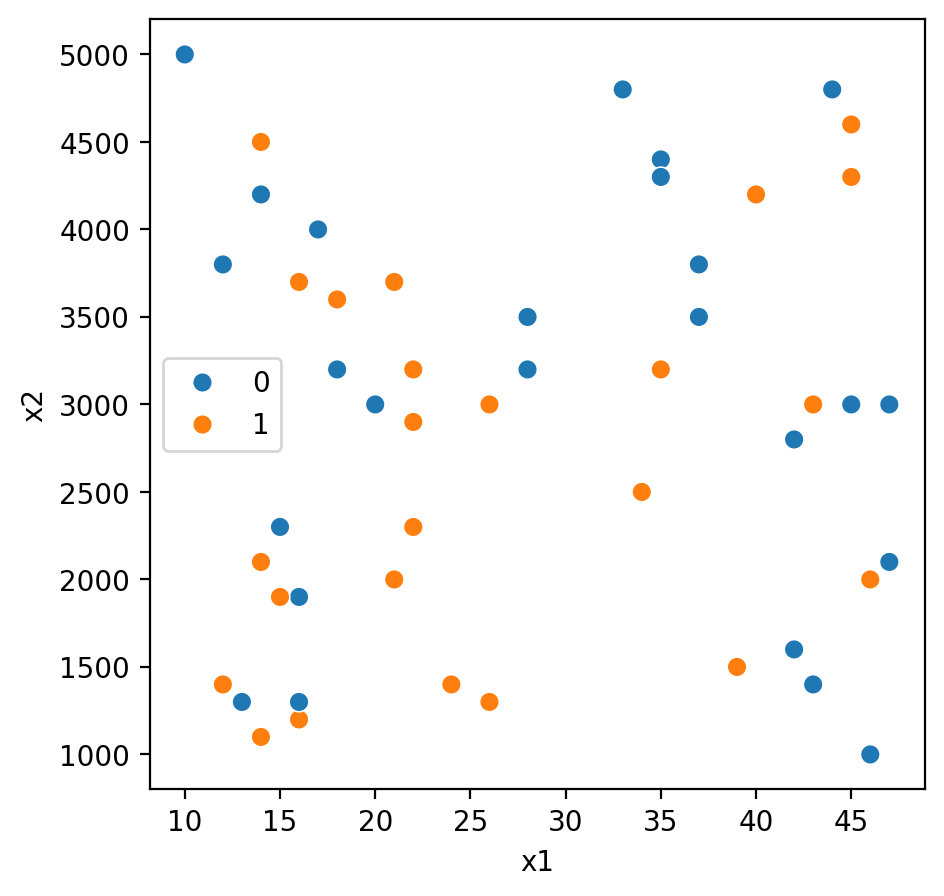

In [11]:
# 데이터 만들기
np.random.seed(12)
x = np.random.randint(10, 51, (50, 2))
y = np.random.randint(0, 2, 50)
x = x * [1, 100]

# 데이터 분포 시각화
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, s=50)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# 2.모델링

- KNN 알고리즘으로 모델을 만들고 학습한다.
- 이웃 개수(n_neighbors)는 3으로 설정한다.

In [12]:
# 불러오기
from sklearn.neighbors import KNeighborsClassifier

# 선언하기
model = KNeighborsClassifier(n_neighbors=3)

# 학습하기
model.fit(x, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# 3.우리 이웃의 색깔은?

- 가장 가까운 3개의 이웃에게 물었다.
- **"이웃님들 우리 별은 무슨 색인가요?"**

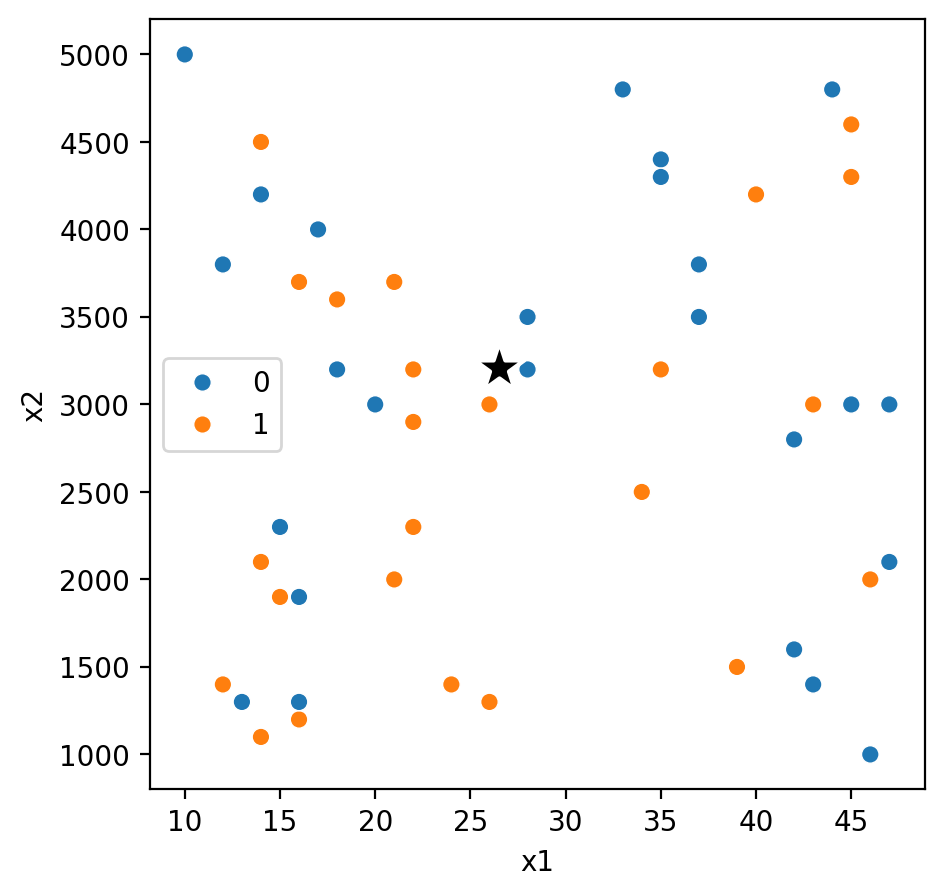

In [13]:
# 우리별 자리
OUR_STAR = np.array([[26.5, 3210]])

# 기본 데이터
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, s=40)

# 별 표시
star = OUR_STAR
sns.scatterplot(x=star[:, 0], y=star[:, 1],
                marker='*',
                color='k',
                s=350)

plt.xlabel('x1')
plt.ylabel('x2')
plt.show()


- **퀴즈!** 검게 변한 우리별 색깔은 무엇일까?

# 4.우리별 색깔 확인

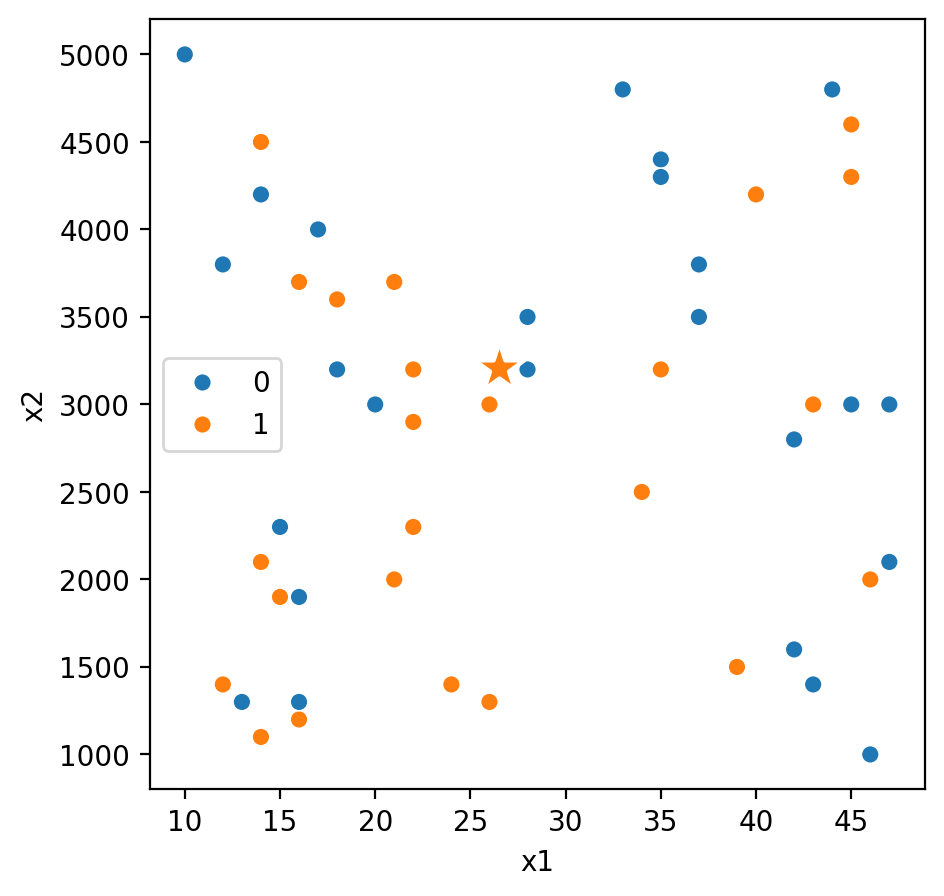

In [14]:
# 기본 데이터
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, s=40)

# 별 색깔 확인
y_pred = model.predict(star)
star_color = 'tab:blue' if y_pred == 0 else 'tab:orange'

# 별 표시
sns.scatterplot(x=star[:, 0], y=star[:, 1],
                marker='*',
                color=star_color,
                s=350)

plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# 5.우리별 이웃 확인

In [15]:
# 별 이웃 찾기
star_neighbor=[]
for n in model.kneighbors(star)[1].ravel():
    star_neighbor.append(x[n].tolist())
star_neighbor = np.array(star_neighbor)

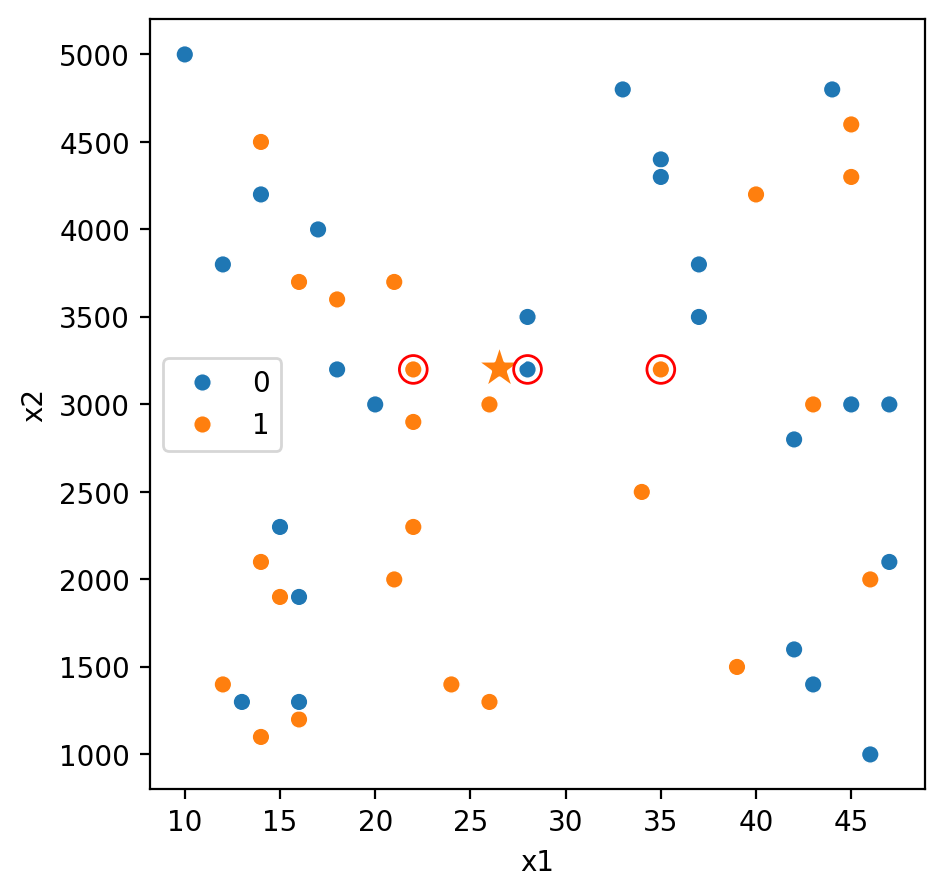

In [16]:
# 기본 데이터
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, s=40)

# 별 표시
sns.scatterplot(x=star[:, 0], y=star[:, 1],
                marker='*',
                color=star_color,
                s=350)

# 이웃 표시
plt.scatter(x=star_neighbor[:, 0], y=star_neighbor[:, 1],
            linewidth=1,
            facecolors='none',
            color='r',
            s=100)

plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# 6.정규화 후 다시 학습

In [17]:
# 모듈 불러오기
from sklearn.preprocessing import MinMaxScaler

# 정규화
scaler = MinMaxScaler()
scaler.fit(x)
x = scaler.transform(x)

# 별 위치도 정규화 반영(OUR_STAR = np.array([[26.5, 3210]))
star = scaler.transform(OUR_STAR)

# 다시 학습
model.fit(x, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# 7.우리별 색깔은?

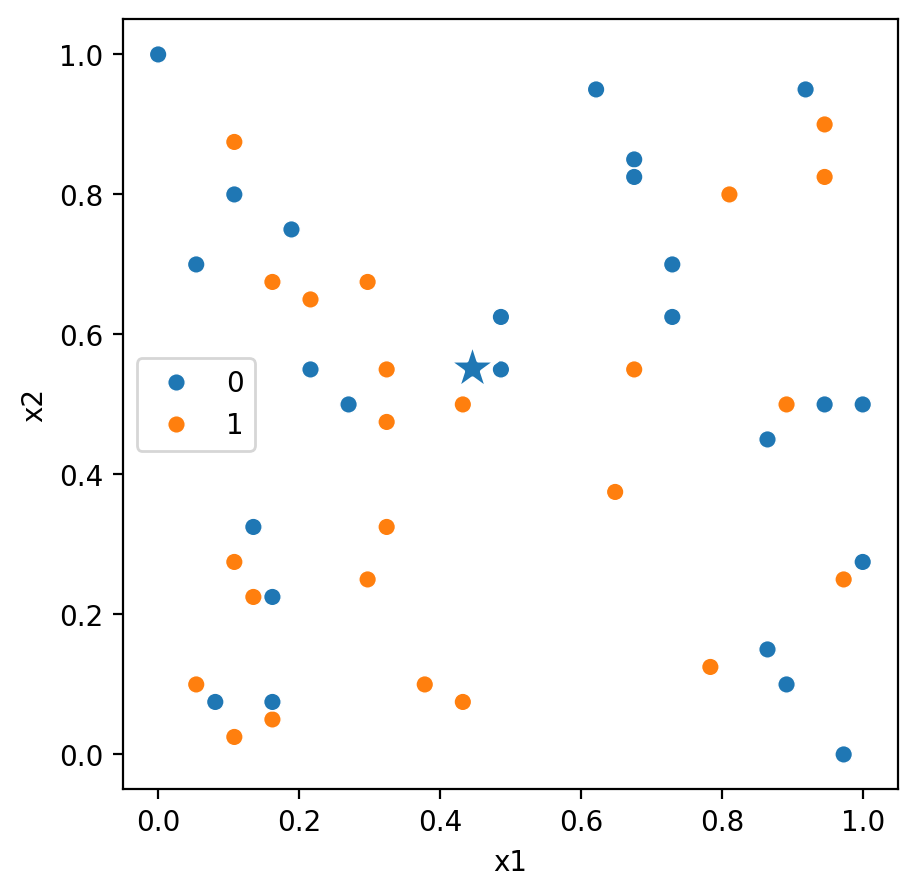

In [18]:
# 기본 데이터
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, s=40)

# 별 색깔 확인
y_pred = model.predict(star)
star_color = 'tab:blue' if y_pred == 0 else 'tab:orange'

# 별 표시
sns.scatterplot(x=star[:, 0], y=star[:, 1],
                marker='*',
                color=star_color,
                s=350)

plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# 8.새로운 이웃 확인

- 파란색 이웃 확인


In [19]:
# 가장 까까운 이웃 찾기
star_neighbor=[]
for n in model.kneighbors(star)[1].ravel():
    star_neighbor.append(x[n].tolist())
star_neighbor = np.array(star_neighbor)

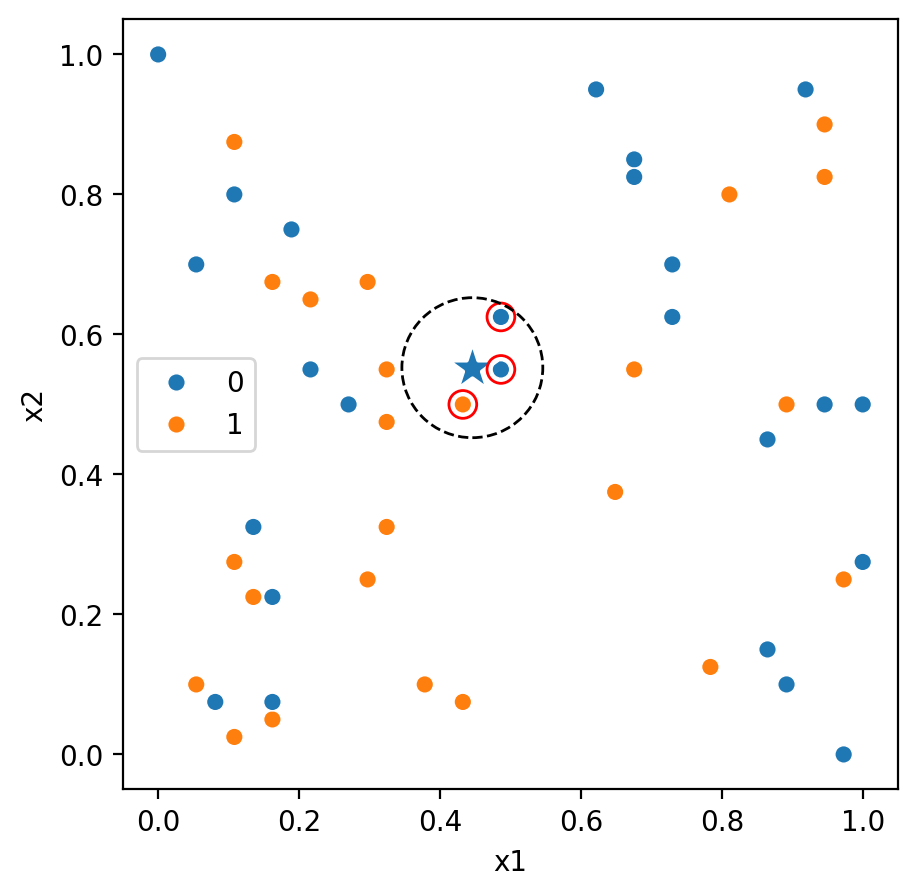

In [20]:
# 기본 데이터
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, s=40)

# 별 표시
sns.scatterplot(x=star[:, 0], y=star[:, 1],
                marker='*',
                color=star_color,
                s=350)

# 이웃 표시
plt.scatter(x=star_neighbor[:,0],
            y=star_neighbor[:,1],
            linewidth=1,
            facecolors='none',
            color='r',
            s=100)

# 원 그리기
circle = plt.Circle((star[0, 0], star[0, 1]), 0.100,
                    color='k',
                    linewidth=1,
                    linestyle='--',
                    fill=False)
plt.gca().add_artist(circle)

plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# 9.이웃 수 늘리기

- 이웃 수(n_neighbors)를 5개로 늘려보자.

In [21]:
# 선언하기
model = KNeighborsClassifier(n_neighbors=5)

# 학습하기
model.fit(x, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# 10. 우리별 색깔은?

- 우리별 색깔은 여전히 파란색일까?
- 가장 가까운 5개 이웃에게 다시 물어보자

In [22]:
# 가장 까까운 이웃 찾기
star_neighbor=[]
for n in model.kneighbors(star)[1].ravel():
    star_neighbor.append(x[n].tolist())
star_neighbor = np.array(star_neighbor)

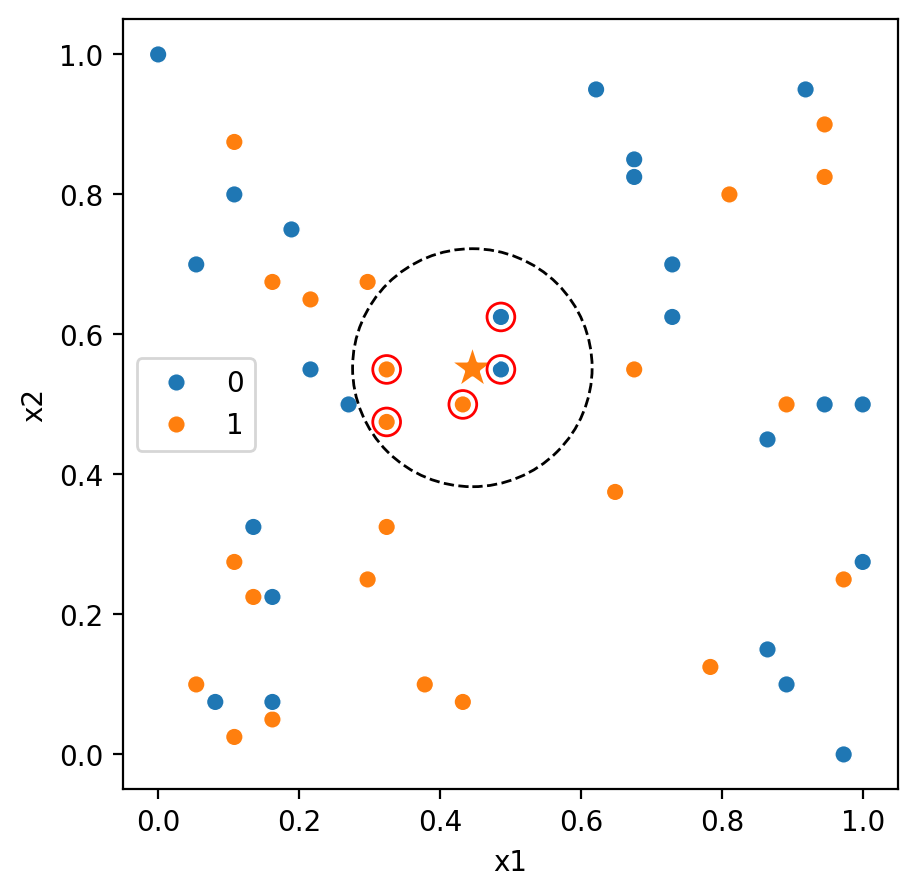

In [23]:
# 기본 데이터
plt.figure(figsize=(5, 5))
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y, s=40)

# 별 색깔 확인
y_pred = model.predict(star)
star_color = 'tab:blue' if y_pred == 0 else 'tab:orange'

# 별 표시
sns.scatterplot(x=star[:, 0], y=star[:, 1],
                marker='*',
                color=star_color,
                s=350)

# 이웃 표시
plt.scatter(x=star_neighbor[:, 0], y=star_neighbor[:, 1],
            linewidth=1,
            facecolors='none',
            color='r',
            s=100)

# 원 그리기
circle = plt.Circle((star[0, 0], star[0, 1]), 0.17,
                    color='k',
                    linewidth=1,
                    linestyle='--',
                    fill=False)
plt.gca().add_artist(circle)

plt.xlabel('x1')
plt.ylabel('x2')
plt.show()